In [12]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

In [13]:
data_dir = Path("../logs/final_experiment/game24")

In [14]:
list(data_dir.rglob("*.json"))

[PosixPath('../logs/final_experiment/game24/B_beta_c/game24_B_beta_c_bedrock_B3_E1_budget50_vth0.5_900_1000_20260817_223127.json'),
 PosixPath('../logs/final_experiment/game24/C_fixed_k2/game24_C_fixed_k2_bedrock_B3_E1_budget50_vth0.5_900_1000_20260818_003244.json'),
 PosixPath('../logs/final_experiment/game24/D_strict_nonparent/game24_D_strict_nonparent_bedrock_B3_E1_budget50_vth0.5_900_1000_20260820_010537.json'),
 PosixPath('../logs/final_experiment/game24/A_parent/game24_A_parent_bedrock_B3_E1_budget50_vth0.5_900_1000_20260817_184855.json')]

In [15]:
files = {
    "A": Path("/Users/bhoomibhat/Documents/Diss/tree-of-thought-llm/logs/final_experiment/game24/A_parent/game24_A_parent_bedrock_B3_E1_budget50_vth0.5_900_1000_20260817_184855.json"),
    "B":Path("/Users/bhoomibhat/Documents/Diss/tree-of-thought-llm/logs/final_experiment/game24/B_beta_c/game24_B_beta_c_bedrock_B3_E1_budget50_vth0.5_900_1000_20260817_223127.json"),
    "C":Path("/Users/bhoomibhat/Documents/Diss/tree-of-thought-llm/logs/final_experiment/game24/C_fixed_k2/game24_C_fixed_k2_bedrock_B3_E1_budget50_vth0.5_900_1000_20260818_003244.json"),
    "D":Path("/Users/bhoomibhat/Documents/Diss/tree-of-thought-llm/logs/final_experiment/game24/D_strict_nonparent/game24_D_strict_nonparent_bedrock_B3_E1_budget50_vth0.5_900_1000_20260820_010537.json")

}

In [16]:
with open(files["A"], "r") as f:
    data_A = json.load(f)

with open(files["B"], "r") as f:
    data_B = json.load(f)

with open(files["C"], "r") as f:
    data_C = json.load(f)

with open(files["D"], "r") as f:
    data_D = json.load(f)

FINAL RESULTS ANALYSIS 

In [23]:
import pandas as pd

def build_puzzle_metrics(records, condition):
    """One row per puzzle, using the fields already in the raw detail log."""
    rows = []
    for r in records:
        usage = r.get("usage_this_puzzle", {}) or {}
        rows.append({
            "puzzle_id":               r["idx"],
            "condition":               condition,
            "solved":                  r["solution"] is not None,
            "nodes_explored":          r["nodes_explored"],
            "candidates_evaluated":    r["candidates_evaluated"],
            "candidates_pruned":       r["candidates_pruned"],
            "num_backtracks_raw":      r["num_backtracks_raw"],
            "num_logical_backtracks":  r["num_logical_backtracks"],
            "mean_jump_size":          r["mean_jump_size"],
            "pct_jumps_gt1":           r["pct_jumps_gt1"],
            "beta_calls":              r["beta_calls"],
            "total_tokens_this_puzzle": usage.get("completion_tokens", 0) + usage.get("prompt_tokens", 0),
        })
    return pd.DataFrame(rows)

df_metrics = pd.concat(
    [
        build_puzzle_metrics(data_A, "A"),
        build_puzzle_metrics(data_B, "B"),
        build_puzzle_metrics(data_C, "C"),
        build_puzzle_metrics(data_D, "D"),
    ],
    ignore_index=True
)

descriptive_table = (
    df_metrics.groupby("condition")
    .agg(
        solved                    = ("solved", "sum"),
        n_puzzles                 = ("solved", "count"),
        nodes_explored_mean       = ("nodes_explored", "mean"),
        candidates_evaluated_mean = ("candidates_evaluated", "mean"),
        candidates_pruned_mean    = ("candidates_pruned", "mean"),
        backtracks_raw_mean       = ("num_backtracks_raw", "mean"),
        logical_backtracks_mean   = ("num_logical_backtracks", "mean"),
        beta_calls_total          = ("beta_calls", "sum"),
        total_tokens              = ("total_tokens_this_puzzle", "sum"),
    )
    .reindex(["A", "B", "C", "D"])
)

descriptive_table["solve_rate_%"] = (descriptive_table["solved"] / descriptive_table["n_puzzles"] * 100).round(1)


descriptive_table = descriptive_table[[
    "solved", "n_puzzles", "solve_rate_%",
    "nodes_explored_mean", "candidates_evaluated_mean", "candidates_pruned_mean",
    "backtracks_raw_mean", "logical_backtracks_mean",
    "beta_calls_total", "total_tokens",
]].round(2)

descriptive_table.rename(columns={
    "solved":                    "Solved (/100)",
    "n_puzzles":                 "N",
    "solve_rate_%":              "Solve rate (%)",
    "nodes_explored_mean":       "Nodes explored (mean)",
    "candidates_evaluated_mean": "Candidates evaluated (mean)",
    "candidates_pruned_mean":    "Candidates pruned (mean)",
    "backtracks_raw_mean":       "Backtracks, raw (mean)",
    "logical_backtracks_mean":   "Backtracks, logical (mean)",
    "beta_calls_total":          "β(c) calls (total)",
    "total_tokens":              "Total tokens",
})


,Solved (/100),N,Solve rate (%),Nodes explored (mean),Candidates evaluated (mean),Candidates pruned (mean),"Backtracks, raw (mean)","Backtracks, logical (mean)",β(c) calls (total),Total tokens
condition,,,,,,,,,,
A,92,100,92.0,18.36,41.73,23.37,0.89,0.89,0,1402836
B,99,100,99.0,18.33,42.38,24.05,0.37,0.35,37,1470272
C,98,100,98.0,18.28,45.49,27.21,0.56,0.56,0,1513645
D,98,100,98.0,18.43,42.09,23.66,0.38,0.38,20,1405848


In [20]:
def event_level_jump_stats(records, condition):
    """Mean jump size computed over every individual backtrack event
    in this condition, pooled across all puzzles 
    'mean_jump_size' field."""
    all_jumps = []
    for r in records:
        for b in r.get("backtracks", []):
            if b.get("jump") is not None:
                all_jumps.append(b["jump"])
    n_events = len(all_jumps)
    if n_events == 0:
        return {"condition": condition, "n_events": 0, "mean_jump": None, "median_jump": None,
                "pct_jumps_gt1": None}
    non_degenerate = sum(1 for j in all_jumps if j > 1)
    return {
        "condition": condition,
        "n_events": n_events,
        "mean_jump": sum(all_jumps) / n_events,
        "pct_jumps_gt1": 100 * non_degenerate / n_events,
    }

import pandas as pd
event_jump_summary_g24 = pd.DataFrame([
    event_level_jump_stats(data_A, "A"),
    event_level_jump_stats(data_B, "B"),
    event_level_jump_stats(data_C, "C"),
    event_level_jump_stats(data_D, "D"),
]).set_index("condition").round(3)

event_jump_summary_g24


,n_events,mean_jump,pct_jumps_gt1
condition,,,
A,89,1.000,0.000
B,37,1.595,48.649
C,56,1.607,60.714
D,38,1.658,52.632


In [ ]:
def event_level_jump_stats(records, condition):
    """Mean jump size computed over every individual backtrack event
    in this condition, pooled across all puzzles
    'mean_jump_size' field."""
    all_events = []
    for r in records:
        for b in r.get("backtracks", []):
            if b.get("jump") is not None:
                all_events.append(b)

    n_events = len(all_events)
    if n_events == 0:
        return {
            "condition": condition, "n_events": 0, "mean_jump": None, "median_jump": None,
            "pct_jumps_gt1": None, "n_degenerate": 0,
            "n_degenerate_at_depth1": 0, "n_degenerate_at_deeper": 0,
        }

    jumps = [b["jump"] for b in all_events]
    non_degenerate = [j for j in jumps if j > 1]
    degenerate_events = [b for b in all_events if b["jump"] == 1]
    degenerate_at_depth1 = sum(1 for b in degenerate_events if b.get("from_depth") == 1)
    degenerate_at_deeper = sum(1 for b in degenerate_events if b.get("from_depth", 0) > 1)

    return {
        "condition": condition,
        "n_events": n_events,
        "mean_jump": sum(jumps) / n_events,
        "pct_jumps_gt1": 100 * len(non_degenerate) / n_events,
        "n_degenerate": len(degenerate_events),
        "n_degenerate_at_depth1": degenerate_at_depth1,
        "n_degenerate_at_deeper": degenerate_at_deeper,
    }

import pandas as pd

event_jump_summary = pd.DataFrame([
    event_level_jump_stats(data_A, "A"),
    event_level_jump_stats(data_B, "B"),
    event_level_jump_stats(data_C, "C"),
    event_level_jump_stats(data_D, "D"),
]).set_index("condition").round(2)

event_jump_summary


,n_events,mean_jump,median_jump,pct_jumps_gt1,n_degenerate,n_degenerate_at_depth1,n_degenerate_at_deeper
condition,,,,,,,
A,89,1.00,1,0.00,89,23,66
B,37,1.59,1,48.65,17,13,4
C,56,1.61,2,60.71,22,22,0
D,38,1.66,2,52.63,16,16,0


In [ ]:
import pandas as pd

def extract_backtrack_events(records, condition):
    """One row per backtrack event, pulling every field needed for the descriptive table"""
    rows = []
    for r in records:
        for event in r.get("backtracks", []):
            rows.append({
                "puzzle_id":                    r["idx"],
                "condition":                    condition,
                "from_depth":                   event.get("from_depth"),
                "to_depth":                      event.get("to_depth"),
                "jump":                         event.get("jump"),
                "degenerate":                   event.get("degenerate"),
                "beta_model_call":              event.get("beta_model_call", False),
                "beta_parse_method":            event.get("beta_parse_method"),
                "cascade":                      event.get("cascade", False),
                "reason":                       event.get("reason"),
                # Condition D bookkeeping only, NaN/absent for A/B/C events
                "no_legal_nonparent":           event.get("no_legal_nonparent"),
                "fallback_to_root":             event.get("fallback_to_root"),
                "model_unrecoverable":          event.get("model_unrecoverable"),
                "invalid_target":               event.get("invalid_target"),
                "fallback_to_deepest_nonparent": event.get("fallback_to_deepest_nonparent"),
            })
    return pd.DataFrame(rows)

events_A = extract_backtrack_events(data_A, "A")
events_B = extract_backtrack_events(data_B, "B")
events_C = extract_backtrack_events(data_C, "C")
events_D = extract_backtrack_events(data_D, "D")

events_all = pd.concat([events_A, events_B, events_C, events_D], ignore_index=True)
events_B.head()


,puzzle_id,condition,from_depth,to_depth,jump,degenerate,beta_model_call,beta_parse_method,cascade,reason,no_legal_nonparent,fallback_to_root,model_unrecoverable,invalid_target,fallback_to_deepest_nonparent
0,904,B,2,0,2,False,True,structured,False,all pruned,None,None,None,None,None
1,906,B,1,0,1,True,True,structured,False,all pruned,None,None,None,None,None
2,906,B,1,0,1,True,True,structured,False,all pruned,None,None,None,None,None
3,912,B,2,0,2,False,True,structured,False,all pruned,None,None,None,None,None
4,912,B,1,0,1,True,True,structured,False,all pruned,None,None,None,None,None


In [ ]:
# Core RQ1 summary needed for reliability of beta(c) target selection


model_events = events_all[events_all["beta_model_call"] == True]

def summarize_beta_behaviour(cond):
    all_ev = events_all[events_all["condition"] == cond]
    mod_ev = model_events[model_events["condition"] == cond]
    jump_counts = mod_ev["jump"].value_counts()

    n_model = len(mod_ev)
    return {
        "total_backtracks":          len(all_ev),
        "beta_model_calls":          n_model,
        "parse_structured":          int((mod_ev["beta_parse_method"] == "structured").sum()),
        "parse_fallback_last_number": int((mod_ev["beta_parse_method"] == "fallback_last_number").sum()),
        "parse_fallback_no_number":  int((mod_ev["beta_parse_method"] == "fallback_no_number").sum()),
        "jump_eq_0_selfreferential": int(jump_counts.get(0, 0)),
        "jump_eq_1_degenerate":      int(jump_counts.get(1, 0)),
        "jump_gt1_nonparent":        int(jump_counts[jump_counts.index > 1].sum()) if n_model else 0,
        "cascades":                  int(mod_ev["cascade"].sum()),
        "pct_structured_%":          round(100 * (mod_ev["beta_parse_method"] == "structured").mean(), 1) if n_model else None,
        "pct_jump_gt1_of_calls_%":   round(100 * jump_counts[jump_counts.index > 1].sum() / n_model, 1) if n_model else None,
    }

beta_behaviour_summary = pd.DataFrame(
    {cond: summarize_beta_behaviour(cond) for cond in ["A", "B", "C", "D"]}
).T

beta_behaviour_summary


,total_backtracks,beta_model_calls,parse_structured,parse_fallback_last_number,parse_fallback_no_number,jump_eq_0_selfreferential,jump_eq_1_degenerate,jump_gt1_nonparent,cascades,pct_structured_%,pct_jump_gt1_of_calls_%
A,89.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
B,37.0,37.0,36.0,1.0,0.0,2.0,17.0,18.0,2.0,97.3,48.6
C,56.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
D,38.0,20.0,20.0,0.0,0.0,0.0,0.0,20.0,0.0,100.0,100.0


In [ ]:
# Condition D only: how the strict non-parent rule resolved every backtrack

d_events = events_all[events_all["condition"] == "D"]

d_resolution_summary = pd.Series({
    "total_backtracks":                 len(d_events),
    "deterministic_root_fallback (from_depth<=1, no model call)": int(d_events["fallback_to_root"].fillna(False).sum()),
    "model_call_valid_first_try":       int(((d_events["beta_model_call"] == True) &
                                              (d_events["model_unrecoverable"].fillna(False) == False) &
                                              (d_events["invalid_target"].fillna(False) == False)).sum()),
    "model_call_unrecoverable_response": int(d_events["model_unrecoverable"].fillna(False).sum()),
    "model_call_invalid_target":         int(d_events["invalid_target"].fillna(False).sum()),
    "fallback_to_deepest_nonparent_used": int(d_events["fallback_to_deepest_nonparent"].fillna(False).sum()),
})

d_resolution_summary


In [ ]:
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar


# Build the paired A vs B solved/unsolved table
def puzzle_solved_lookup(records):
    return {r["idx"]: (r["solution"] is not None) for r in records}

solved_A = puzzle_solved_lookup(data_A)
solved_B = puzzle_solved_lookup(data_B)

puzzle_ids = sorted(solved_A.keys())
assert puzzle_ids == sorted(solved_B.keys()), "A and B must cover the identical puzzle set"

solved_df = pd.DataFrame({
    "puzzle_id": puzzle_ids,
    "A_solved": [solved_A[i] for i in puzzle_ids],
    "B_solved": [solved_B[i] for i in puzzle_ids],
})


# 2x2 contingency table
contingency = pd.crosstab(
    solved_df["A_solved"].map({True: "A solved", False: "A unsolved"}),
    solved_df["B_solved"].map({True: "B solved", False: "B unsolved"})
).reindex(
    index=["A solved", "A unsolved"],
    columns=["B solved", "B unsolved"],
    fill_value=0
)

contingency


B_solved,B solved,B unsolved
A_solved,,
A solved,92,0
A unsolved,7,1


In [ ]:

# Solve-rate difference

n = len(solved_df)
solve_rate_A = solved_df["A_solved"].mean() * 100
solve_rate_B = solved_df["B_solved"].mean() * 100

print(f"A solve rate: {solve_rate_A:.1f}%  ({solved_df['A_solved'].sum()}/{n})")
print(f"B solve rate: {solve_rate_B:.1f}%  ({solved_df['B_solved'].sum()}/{n})")
print(f"Difference (B - A): {solve_rate_B - solve_rate_A:+.1f} percentage points")


A solve rate: 92.0%  (92/100)
B solve rate: 99.0%  (99/100)
Difference (B - A): +7.0 percentage points


In [ ]:

# McNemar exact test PRIMARY RQ2 RESULT


b = int(contingency.loc["A unsolved", "B solved"])  # discordant pairs favoring B
c = int(contingency.loc["A solved", "B unsolved"])  # discordant pairs favoring A

mcnemar_result = mcnemar(contingency.values, exact=True)

print("=== RQ2 primary result: A vs B, exact McNemar, uncorrected ===")
print(f"Discordant pairs favoring B (A unsolved -> B solved): {b}")
print(f"Discordant pairs favoring A (A solved -> B unsolved): {c}")
print(f"McNemar exact statistic: {mcnemar_result.statistic}")
print(f"McNemar exact p-value: {mcnemar_result.pvalue:.4f}")
print(f"Significant at alpha=0.05: {mcnemar_result.pvalue < 0.05}")


=== RQ2 primary result: A vs B, exact McNemar, uncorrected ===
Discordant pairs favoring B (A unsolved -> B solved): 7
Discordant pairs favoring A (A solved -> B unsolved): 0
McNemar exact statistic: 0.0
McNemar exact p-value: 0.0156
Significant at alpha=0.05: True


In [ ]:
# For context: what the Holm-corrected p-value would be if this test were
# counted as one of the 6 exploratory pairwise comparisons

six_way_context = pd.Series({
    "raw_p_this_test": mcnemar_result.pvalue,
    "holm_adjusted_p_if_treated_as_1_of_6": 0.094,  # from the earlier 6-way Holm sweep
    "note": "RQ2's reported result uses the raw p above, per the pre-registration decision.",
})

six_way_context


In [ ]:
import pandas as pd
from scipy.stats import friedmanchisquare

# RQ3 search efficiency: nodes explored, candidates evaluated, candidates pruned
# Reuses df_metrics from Step 1 (one row per puzzle x condition)

efficiency_metrics = ["nodes_explored", "candidates_evaluated", "candidates_pruned"]

# Descriptive statistics
efficiency_descriptives = (
    df_metrics.groupby("condition")[efficiency_metrics]
    .agg(["mean", "median", "std", "min", "max"])
    .reindex(["A", "B", "C", "D"])
    .round(2)
)

print("=== Descriptive statistics: search efficiency, A/B/C/D ===")
efficiency_descriptives


In [ ]:
# one column per condition, one row per puzzle

nodes = df_metrics.pivot(index="puzzle_id", columns="condition", values="nodes_explored")[["A", "B", "C", "D"]]
candidates = df_metrics.pivot(index="puzzle_id", columns="condition", values="candidates_evaluated")[["A", "B", "C", "D"]]
pruned = df_metrics.pivot(index="puzzle_id", columns="condition", values="candidates_pruned")[["A", "B", "C", "D"]]

# sanity check: no missing puzzles in any condition before running paired tests
for name, wide in [("nodes_explored", nodes), ("candidates_evaluated", candidates), ("candidates_pruned", pruned)]:
    assert wide.isna().sum().sum() == 0, f"{name} has missing values across conditions"


In [ ]:
# Friedman omnibus test, one per metric

friedman_nodes      = friedmanchisquare(nodes["A"], nodes["B"], nodes["C"], nodes["D"])
friedman_candidates = friedmanchisquare(candidates["A"], candidates["B"], candidates["C"], candidates["D"])
friedman_pruned      = friedmanchisquare(pruned["A"], pruned["B"], pruned["C"], pruned["D"])

# Consolidated RQ3 results table

rq3_friedman_results = pd.DataFrame({
    "metric": ["nodes_explored", "candidates_evaluated", "candidates_pruned"],
    "friedman_chi2": [friedman_nodes.statistic, friedman_candidates.statistic, friedman_pruned.statistic],
    "p_value": [friedman_nodes.pvalue, friedman_candidates.pvalue, friedman_pruned.pvalue],
}).round(3)

rq3_friedman_results["significant_at_0.05"] = rq3_friedman_results["p_value"] < 0.05

print("=== RQ3 omnibus tests: search efficiency, A vs B vs C vs D (n=100) ===")
rq3_friedman_results


In [ ]:
# RQ3 conclusion, from the numbers above only, no further significance tests are run.

rq3_conclusion = efficiency_descriptives.loc[:, (slice(None), "mean")]
rq3_conclusion.columns = [f"{m} (mean)" for m, _ in rq3_conclusion.columns]

print("=== RQ3 conclusion: mean search-efficiency cost is flat across A-D ===")
rq3_conclusion


VISUALS

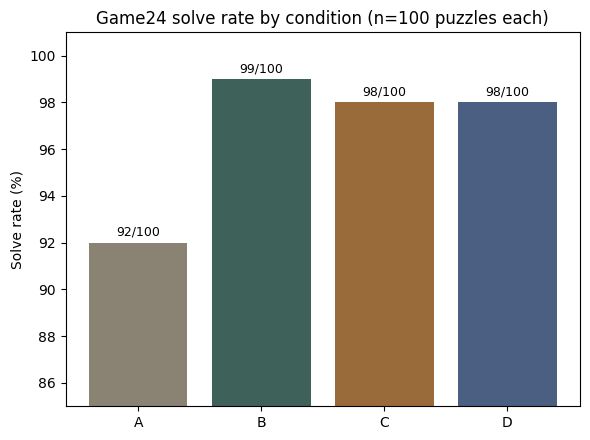

In [20]:
import matplotlib.pyplot as plt

conditions = ["A", "B", "C", "D"]
palette = {"A": "#8A8272", "B": "#3E6259", "C": "#9A6B3A", "D": "#4A5F82"}

solve_counts = df_metrics.groupby("condition")["solved"].sum().reindex(conditions)
solve_rate = (solve_counts / 100 * 100)

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(conditions, solve_rate, color=[palette[c] for c in conditions])
ax.set_ylim(85, 101)
ax.set_ylabel("Solve rate (%)")
ax.set_title("Game24 solve rate by condition (n=100 puzzles each)")
for bar, count in zip(bars, solve_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{count}/100", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("game24_solve_rate.png", dpi=150)
plt.show()


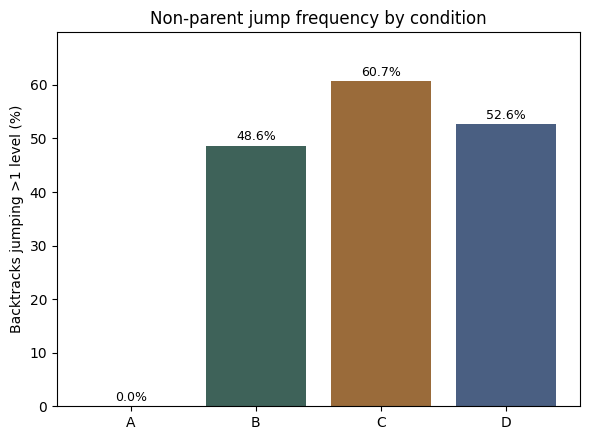

In [25]:
import matplotlib.pyplot as plt

conditions = ["A", "B", "C", "D"]
palette = {"A": "#8A8272", "B": "#3E6259", "C": "#9A6B3A", "D": "#4A5F82"}

def event_level_jump_stats(records, condition):
    all_events = []
    for r in records:
        for b in r.get("backtracks", []):
            if b.get("jump") is not None:
                all_events.append(b)
    n_events = len(all_events)
    if n_events == 0:
        return {"condition": condition, "n_events": 0, "pct_jumps_gt1": None}
    jumps = [b["jump"] for b in all_events]
    non_degenerate = sum(1 for j in jumps if j > 1)
    return {"condition": condition, "n_events": n_events,
            "pct_jumps_gt1": 100 * non_degenerate / n_events}

event_jump_summary_g24 = {
    row["condition"]: row
    for row in [event_level_jump_stats(data_A, "A"), event_level_jump_stats(data_B, "B"),
                event_level_jump_stats(data_C, "C"), event_level_jump_stats(data_D, "D")]
}
pct_jumps = [event_jump_summary_g24[c]["pct_jumps_gt1"] for c in conditions]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(conditions, pct_jumps, color=[palette[c] for c in conditions])
ax.set_ylabel("Backtracks jumping >1 level (%)")
ax.set_title("Non-parent jump frequency by condition")
for bar, v in zip(bars, pct_jumps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_ylim(0, max(pct_jumps) * 1.15)
plt.tight_layout()
plt.savefig("game24_pct_jumps_gt1_event_level.png", dpi=150)
plt.show()


/var/folders/n2/qc4kd9xx1fvct6t2yppc51k00000gn/T/ipykernel_45177/2253699837.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=conditions, patch_artist=True, showfliers=False)


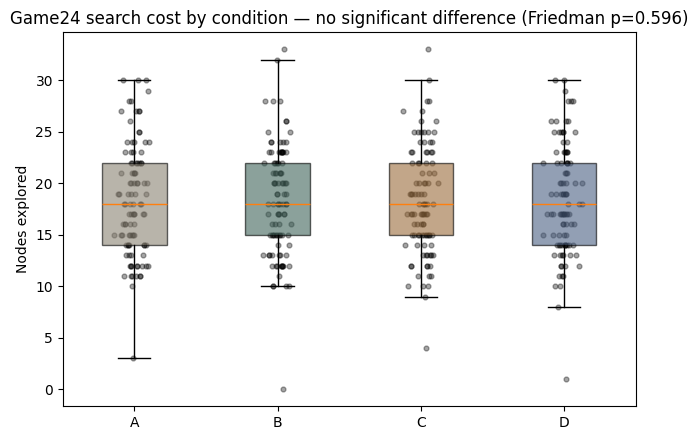

In [22]:
import numpy as np

fig, ax = plt.subplots(figsize=(6.5, 4.5))
data_to_plot = [df_metrics.loc[df_metrics["condition"] == c, "nodes_explored"] for c in conditions]
bp = ax.boxplot(data_to_plot, labels=conditions, patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], conditions):
    patch.set_facecolor(palette[c])
    patch.set_alpha(0.6)
for i, c in enumerate(conditions):
    y = df_metrics.loc[df_metrics["condition"] == c, "nodes_explored"]
    x = np.random.normal(i + 1, 0.05, size=len(y))
    ax.scatter(x, y, alpha=0.35, s=12, color="black")
ax.set_ylabel("Nodes explored")
ax.set_title("Game24 search cost by condition — no significant difference (Friedman p=0.596)")
plt.tight_layout()
plt.savefig("game24_nodes_explored_boxplot.png", dpi=150)
plt.show()


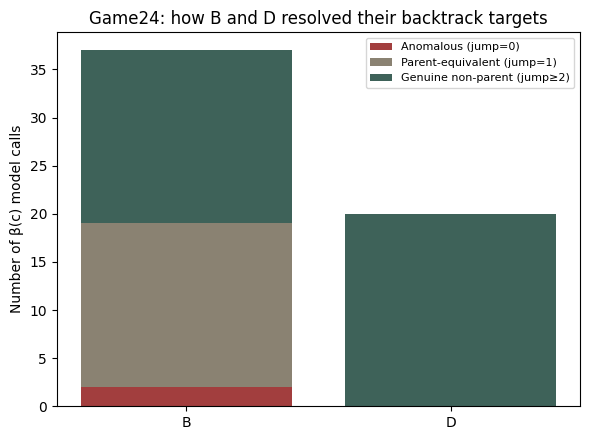

In [23]:
def jump_category_counts(cond, model_events_df):
    ev = model_events_df[model_events_df["condition"] == cond]
    jumps = ev["jump"]
    return {
        "Anomalous (jump=0)":       (jumps == 0).sum(),
        "Parent-equivalent (jump=1)": (jumps == 1).sum(),
        "Genuine non-parent (jump≥2)": (jumps >= 2).sum(),
    }

categories = ["Anomalous (jump=0)", "Parent-equivalent (jump=1)", "Genuine non-parent (jump≥2)"]
cat_colors = ["#A23E3E", "#8A8272", "#3E6259"]

b_counts = jump_category_counts("B", model_events)  # from RQ1 step
d_counts = jump_category_counts("D", model_events)

fig, ax = plt.subplots(figsize=(6, 4.5))
bottom_b, bottom_d = 0, 0
for cat, color in zip(categories, cat_colors):
    ax.bar("B", b_counts[cat], bottom=bottom_b, color=color, label=cat)
    ax.bar("D", d_counts[cat], bottom=bottom_d, color=color)
    bottom_b += b_counts[cat]
    bottom_d += d_counts[cat]
ax.set_ylabel("Number of β(c) model calls")
ax.set_title("Game24: how B and D resolved their backtrack targets")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("game24_beta_jump_categories.png", dpi=150)
plt.show()


In [24]:
import pandas as pd

def extract_token_row(r, condition):
    usage = r.get("usage_this_puzzle", {}) or {}
    return {
        "puzzle_id": r["idx"],
        "condition": condition,
        "completion_tokens": usage.get("completion_tokens", 0),
        "prompt_tokens": usage.get("prompt_tokens", 0),
        "total_tokens": usage.get("completion_tokens", 0) + usage.get("prompt_tokens", 0),
        "cost": usage.get("cost", 0.0),
    }

df_tokens_g24 = pd.concat(
    [
        pd.DataFrame([extract_token_row(r, "A") for r in data_A]),
        pd.DataFrame([extract_token_row(r, "B") for r in data_B]),
        pd.DataFrame([extract_token_row(r, "C") for r in data_C]),
        pd.DataFrame([extract_token_row(r, "D") for r in data_D]),
    ],
    ignore_index=True
)

token_summary_g24 = (
    df_tokens_g24.groupby("condition")
    .agg(
        total_completion_tokens=("completion_tokens", "sum"),
        total_prompt_tokens=("prompt_tokens", "sum"),
        total_tokens=("total_tokens", "sum"),
        mean_tokens_per_puzzle=("total_tokens", "mean"),
        total_cost_usd=("cost", "sum"),
        mean_cost_per_puzzle_usd=("cost", "mean"),
    )
    .reindex(["A", "B", "C", "D"])
    .round(2)
)

token_summary_g24


,total_completion_tokens,total_prompt_tokens,total_tokens,mean_tokens_per_puzzle,total_cost_usd,mean_cost_per_puzzle_usd
condition,,,,,,
A,394882,1007954,1402836,14028.36,2.98,0.03
B,437259,1033013,1470272,14702.72,3.22,0.03
C,424546,1089099,1513645,15136.45,3.21,0.03
D,412275,993573,1405848,14058.48,3.05,0.03


In [ ]:
from scipy.stats import friedmanchisquare

def token_friedman(df_tokens, conditions=["A","B","C","D"]):
    wide = df_tokens.pivot(index="puzzle_id", columns="condition", values="total_tokens")[conditions]
    result = friedmanchisquare(*[wide[c] for c in conditions])
    print(f"Friedman on total_tokens: chi2={result.statistic:.3f}, p={result.pvalue:.4f}")
    return result

token_friedman(df_tokens_g24)   


Friedman on total_tokens: chi2=0.300, p=0.9600


FriedmanchisquareResult(statistic=np.float64(0.2999999999999545), pvalue=np.float64(0.9600284803068861))